# COMP 4449 – Capstone Project

## 1. Project Overview and Research Objective

### What is happening
This project investigates whether classical statistical time-series models can independently characterize short-term behavior in the Denver housing market and how those results compare to Zillow’s proprietary home value forecasts. It uses the Zillow Home Value Index (ZHVI) to analyze historical home value trends and the Zillow Home Value Forecast (ZHVF) as an external benchmark for expected future price movements. The analysis is framed as a **time-series forecasting problem**, where housing values are observed over time rather than predicted from static features.

### Why this is important
Understanding housing market trends and forecasts has practical implications for homeowners, buyers, investors, and policymakers, particularly when publicly available data can be used to assess or validate widely cited market forecasts.

### Research Question
How has the Denver housing market evolved over time, and how can historical home value trends be used to forecast near-term future prices? Additionally, how do model-based forecasts derived from historical data compare to Zillow’s published housing market expectations?

### Novelty and Real-World Impact

This project is novel in its approach rather than its data source. While Zillow’s Home Value Index and forecast products are widely cited, their underlying methodologies are proprietary and opaque. This work demonstrates that transparent, classical statistical time-series models trained solely on publicly available historical data can independently arrive at similar short-term market conclusions.

From a real-world perspective, this has direct implications for homeowners, buyers, investors, and policymakers. It shows that market stabilization signals can be identified without reliance on proprietary tools, allowing independent validation of widely referenced forecasts. This approach empowers analysts and decision-makers to critically assess housing market outlooks using reproducible and interpretable methods.




## 2. Environment Setup and Library Imports

### What is happening
In this section, the Python environment is initialized by importing the core libraries required for data handling, visualization, and time-series analysis. The analysis is conducted within JupyterLab on a Linux desktop system, using a Conda-managed Python environment to ensure reproducibility and package consistency. These imports establish the foundational tools used throughout the remainder of the project.

### Why this is important
A properly configured environment is essential for executing time-series analysis workflows without errors or inconsistencies. This project relies on specialized libraries for statistical testing, rolling calculations, and autocorrelation diagnostics that extend beyond base Python functionality. Verifying that these libraries are available and correctly imported ensures that subsequent analysis steps run reliably and produce reproducible results.

### Tools and Libraries Used
- **pandas**: Data loading, cleaning, reshaping, and feature engineering  
- **numpy**: Numerical computations and array-based operations  
- **matplotlib**: Visualization of historical trends and engineered features  
- **statsmodels**: Statistical testing and time-series diagnostics (e.g., ADF tests, ACF/PACF)


In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (12,6)
pd.set_option("display.max_columns", None)


In [183]:
import sys

## 3. Loading the Zillow Datasets

### What is happening
In this section, the Zillow datasets are loaded into the analysis environment using Python’s `pandas` library. Two separate CSV files are read:

- `ZHVI.csv` — historical Zillow Home Value Index (observed home values)
- `ZHVF.csv` — Zillow Home Value Forecast data (percentage-based projections)

Each dataset is loaded into its own DataFrame to keep historical observations and forecasted values clearly separated throughout the analysis. Initial inspection is performed using `.head()` and `.info()` to verify successful loading, column structure, data types, and overall dimensions.

This step also confirms that the files were downloaded correctly, renamed consistently, and placed in the expected project directory.

### Why this is important
Data loading is a foundational step for the entire workflow. Errors at this stage would propagate through filtering, reshaping, feature engineering, and modeling, potentially invalidating results.

Maintaining a clear separation between ZHVI and ZHVF is critical because:
- **ZHVI** contains real, observed historical home values
- **ZHVF** contains forecasted percentage changes produced by Zillow’s proprietary models

Treating these datasets independently prevents accidental mixing of observed data with forecasts, which would compromise the validity of both analysis and modeling.

#### Feature Labeling and Augmentation

Although this project is framed as a time-series forecasting task rather than a supervised learning problem with explicit class labels, feature augmentation is performed through engineered temporal transformations. Month-over-month percent change, year-over-year percent change, and rolling averages act as derived labels that capture short-term volatility, medium-term momentum, and long-term trend behavior.

These augmented features enable richer interpretation of market dynamics and serve as inputs for diagnostics and model justification, fulfilling the role of labeled signals in a time-dependent forecasting context.

## Key Checks Performed
- Verified both datasets load without errors
- Confirmed presence of geographic metadata (RegionName, RegionType, StateName)
- Verified time-based columns spanning multiple years
- Ensured numeric values are stored in appropriate floating-point formats

### Outcome
At the conclusion of this step, both Zillow datasets are successfully loaded, validated, and ready for geographic filtering and time-series transformation in subsequent sections.


In [184]:
zhvi = pd.read_csv("data/ZHVI.csv")
zhvf = pd.read_csv("data/ZHVF.csv")

zhvi.shape, zhvf.shape


((895, 364), (895, 9))

## Section 4 — Filtering Zillow Data for Denver

### What this section does
In this section, the analysis is narrowed to **Denver-specific housing data** by filtering the Zillow ZHVI dataset using the `RegionName` field. The value `"Denver, CO"` is selected, which corresponds to Zillow’s definition of the **Denver Metropolitan Statistical Area (MSA)**.

Because the raw Zillow datasets include housing data for thousands of regions across the United States, this filtering step isolates only the observations relevant to the Denver housing market. All subsequent transformations, visualizations, and modeling steps are performed on this filtered subset.

### Why this step is important
- The Zillow datasets span **many geographic regions**, including cities, counties, metros, and states
- Analyzing all regions together would mix unrelated housing markets and invalidate conclusions
- Filtering establishes a **clear and consistent geographic scope**, which is necessary for:
  - Time-series trend analysis  
  - Feature engineering  
  - Visualization  
  - Forecast comparison and interpretation  

This step defines the **spatial boundary** of the project and ensures that all results are geographically coherent and focused on a single housing market.

### Outcome
At the end of this section, the dataset contains only Denver MSA observations, providing a clean and well-defined foundation for time-series reshaping, feature engineering, and forecasting analysis in later sections.


In [185]:
denver_zhvi = zhvi[zhvi["RegionName"] == "Denver, CO"]
denver_zhvi.shape


(1, 364)

## Section 5 — Reshaping ZHVI Data from Wide to Long Format

### What this section does
After filtering the Zillow ZHVI dataset for Denver, the data still exists in a **wide time-series format**, where each column represents a different month (e.g., `1996-02-29`, `1996-03-31`, etc.).

In this section, the dataset is **reshaped into long format**, where:
- Each row represents a **single monthly observation**
- All dates are stored in a single `Date` column
- Home values are stored in a single numeric `ZHVI` column

This transformation converts the dataset into a structure that is suitable for time-series analysis, feature engineering, and visualization.

### Why this step is important
Most time-series methods in Python require data to be in **long (tidy) format**. Reshaping the data enables:

- Chronological sorting of observations
- Calculation of month-over-month and year-over-year changes
- Application of rolling window statistics
- Time-based plotting using standard visualization libraries

Without converting the dataset to long format, it would not be possible to perform meaningful temporal analysis or statistical modeling.

### Outcome
At the end of this section, the Denver ZHVI data exists as a clean, chronologically ordered time series, forming the foundation for feature engineering, visualization, and forecasting in subsequent sections.


In [186]:
date_cols = denver_zhvi.columns[5:]

denver_long = denver_zhvi.melt(
    id_vars=["RegionID","SizeRank","RegionName","RegionType","StateName"],
    value_vars=date_cols,
    var_name="Date",
    value_name="ZHVI"
)

denver_long["Date"] = pd.to_datetime(denver_long["Date"])
denver_long = denver_long.sort_values("Date").reset_index(drop=True)

denver_long.head()


,RegionID,SizeRank,RegionName,RegionType,StateName,Date,ZHVI
0,394530,19,"Denver, CO",msa,CO,1996-02-29,138820.347546
1,394530,19,"Denver, CO",msa,CO,1996-03-31,140123.633033
2,394530,19,"Denver, CO",msa,CO,1996-04-30,141638.674660
3,394530,19,"Denver, CO",msa,CO,1996-05-31,143297.420980
4,394530,19,"Denver, CO",msa,CO,1996-06-30,144443.453257


## Section 6 — Feature Engineering for Time-Series Analysis

### What this section does
To better understand temporal dynamics in the Denver housing market, this section engineers several **time-based features** derived from the historical ZHVI series. These features are designed to capture short-term volatility, long-term momentum, and underlying trend behavior that are not directly observable from raw home values alone.

After reshaping the ZHVI data into long format, the following features are computed:

- **Month-over-month percent change**: Captures short-term price movements and seasonal fluctuations  
- **Year-over-year percent change**: Measures longer-term momentum while controlling for seasonality  
- **12-month rolling average**: Smooths short-term noise to highlight the underlying market trend  

Together, these features transform raw price levels into interpretable signals that describe how the housing market evolves over time.

### Why this step is important
Raw ZHVI values represent absolute home prices but do not explain *how* prices are changing. Feature engineering enables:

- Quantification of short-term volatility  
- Identification of long-term growth or decline trends  
- Comparison of current conditions to historical baselines  
- Detection of market acceleration, slowdown, or reversal  

These engineered features provide the analytical foundation for visualization, statistical testing, and time-series modeling in later sections.

### Outcome
At the end of this section, the Denver housing dataset includes multiple engineered features that capture complementary aspects of market behavior, enabling richer analysis than raw price levels alone.


In [187]:
df = denver_long.copy()

df["pct_change"] = df["ZHVI"].pct_change()
df["rolling_12mo"] = df["ZHVI"].rolling(12).mean()
df["yoy_change"] = df["ZHVI"].pct_change(12)

df.tail()


,RegionID,SizeRank,RegionName,RegionType,StateName,Date,ZHVI,pct_change,rolling_12mo,yoy_change
354,394530,19,"Denver, CO",msa,CO,2025-08-31,572356.623409,-0.007480,578828.454271,-0.029942
355,394530,19,"Denver, CO",msa,CO,2025-09-30,568971.032300,-0.005915,577370.974624,-0.029823
356,394530,19,"Denver, CO",msa,CO,2025-10-31,566238.691930,-0.004802,575953.724624,-0.029159
357,394530,19,"Denver, CO",msa,CO,2025-11-30,562420.888379,-0.006742,574449.095881,-0.031105
358,394530,19,"Denver, CO",msa,CO,2025-12-31,559554.313319,-0.005097,572900.814497,-0.032137


## Section 7 — ZHVI Trend with 12-Month Rolling Average

### What this section does
This section visualizes the raw Zillow Home Value Index (ZHVI) for the Denver metropolitan area over time, with a **12-month rolling average** overlaid on the same chart.

The rolling average smooths short-term fluctuations and highlights the longer-term housing price trend. Plotting both series together allows us to visually separate temporary volatility from sustained structural movements in the housing market.

### Why this step is important
Overlaying a rolling average helps to:
- Identify long-term growth or decline trends  
- Reduce noise caused by short-term price fluctuations  
- Improve economic interpretation of housing cycles  
- Inform later modeling decisions related to trend and stationarity  

### Key takeaway
*While monthly ZHVI values fluctuate, the 12-month rolling average reveals the underlying long-term trajectory of Denver home values.*


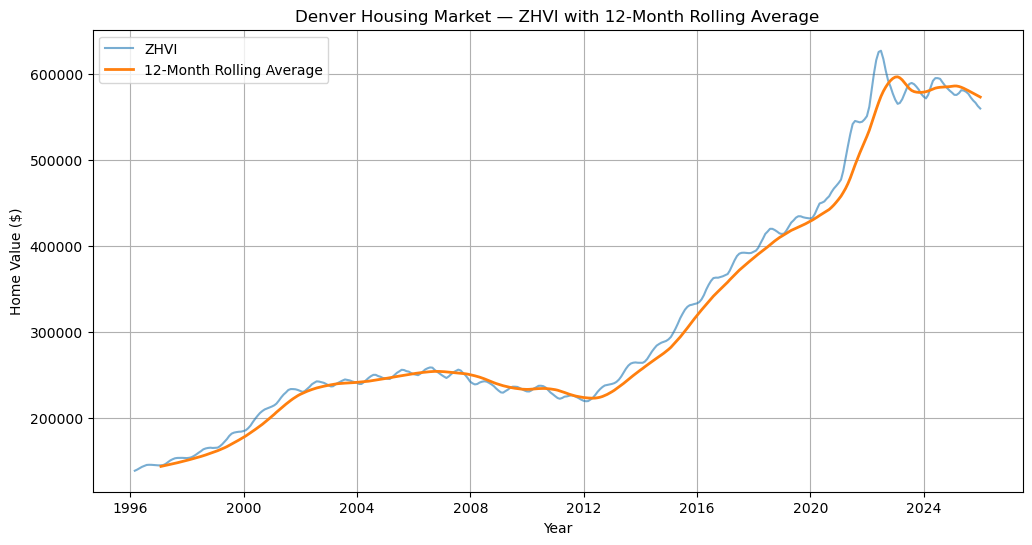

In [188]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["ZHVI"], label="ZHVI", alpha=0.6)
plt.plot(df["Date"], df["rolling_12mo"], label="12-Month Rolling Average", linewidth=2)

plt.title("Denver Housing Market — ZHVI with 12-Month Rolling Average")
plt.xlabel("Year")
plt.ylabel("Home Value ($)")
plt.legend()
plt.grid(True)

plt.show()


### Interpretation of ZHVI Trend with 12-Month Rolling Average

_**The raw ZHVI trend and its 12-month rolling average show that Denver home values follow long-term upward cycles with clear boom, correction, and recovery phases rather than short-term volatility.**_

This visualization combines the raw ZHVI time series with its 12-month rolling average to provide both short-term detail and long-term trend context. The raw ZHVI line captures monthly fluctuations in home values, while the rolling average smooths these variations to highlight broader market direction.

The plot shows a clear long-term upward trend in Denver home values, interrupted by distinct market cycles. A steady rise is visible through the late 1990s and early 2000s, followed by a downturn during the 2007–2009 housing crisis. After reaching a trough around 2011–2012, the market enters a prolonged expansion phase, accelerating sharply after 2020.

The rolling average reduces noise and clarifies turning points in the market. Its gradual flattening and slight decline toward the most recent observations suggest a cooling phase following peak values. This combined visualization demonstrates that the ZHVI series is dominated by trend behavior rather than stationary fluctuations, motivating further time-series diagnostics and transformations.


## Section 8 — Month-over-Month Percent Change in ZHVI

### What this section does

This section visualizes the **month-over-month percent change** in the Zillow Home Value Index (ZHVI) for the Denver metropolitan area. Rather than focusing on absolute home value levels, this transformation measures the **relative change in prices from one month to the next**.

By plotting percent change over time, this section highlights short-term price movements, volatility, and periods of rapid acceleration or deceleration in the housing market.

---

### Why this step is important

Month-over-month percent change is a standard transformation in economic and financial time-series analysis because it:

- Emphasizes short-term price dynamics rather than long-term trends  
- Helps identify periods of heightened volatility or instability  
- Removes scale effects inherent in raw price levels  
- Provides insight into whether the series exhibits stationary behavior  

Analyzing monthly percent changes allows us to better understand the underlying behavior of the housing market and informs later modeling decisions, particularly those related to differencing and time-series forecasting.


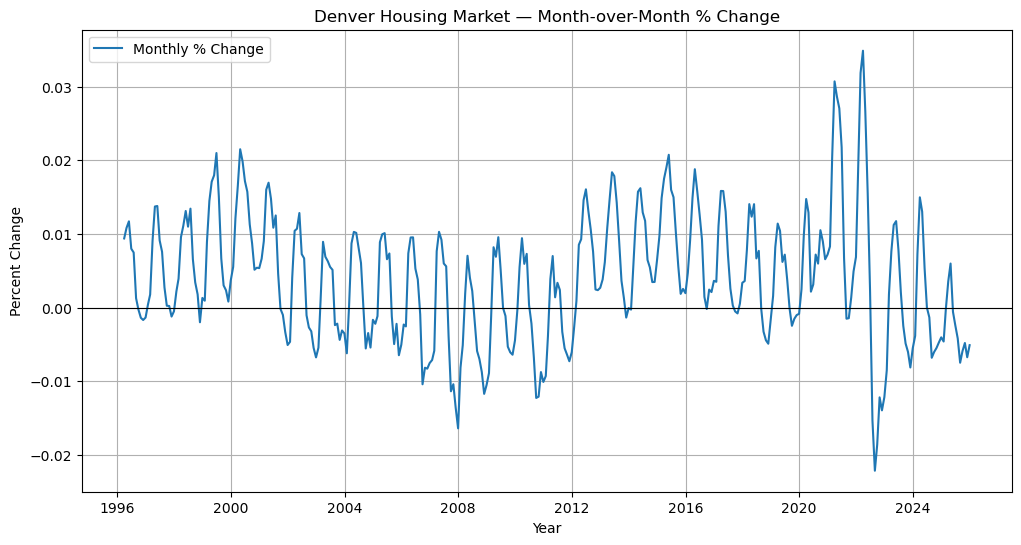

In [189]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["pct_change"], label="Monthly % Change")

plt.title("Denver Housing Market — Month-over-Month % Change")
plt.xlabel("Year")
plt.ylabel("Percent Change")
plt.axhline(0, color="black", linewidth=0.8)
plt.legend()
plt.grid(True)

plt.show()


### Interpretation of Month-over-Month Percentage Change

_**Month-over-month changes reveal short-term volatility and seasonality in the Denver housing market, highlighting rapid accelerations and contractions that are not visible in the raw price trend.**_

The month-over-month percentage change plot captures short-term price dynamics by measuring relative changes in ZHVI from one month to the next. Unlike raw price levels, this transformation emphasizes volatility and seasonal behavior rather than long-term growth.

The series oscillates frequently around zero, indicating that monthly price movements are generally modest but persistent. Seasonal patterns appear consistently across years, while periods of economic stress—such as the 2008 financial crisis and the post-2022 market adjustment—are marked by increased volatility and more pronounced negative values.

Although month-over-month changes provide limited insight into long-term market direction, they are effective for identifying short-term instability and abrupt shifts in housing conditions. This reinforces the need for additional smoothing, diagnostics, and longer-horizon features in subsequent analysis.


## Section 9 — Year-over-Year Percent Change in ZHVI

### What this section does

This section visualizes the year-over-year percent change in ZHVI for Denver by comparing each month’s home value to the same month one year earlier. This transformation focuses on longer-term price momentum rather than short-term fluctuations.

### Why this step is important

Year-over-year percent change:
- Controls for seasonal effects in housing data  
- Highlights sustained periods of market growth or contraction  
- Is commonly used in housing market and macroeconomic analysis  
- Helps distinguish structural trends from short-term volatility


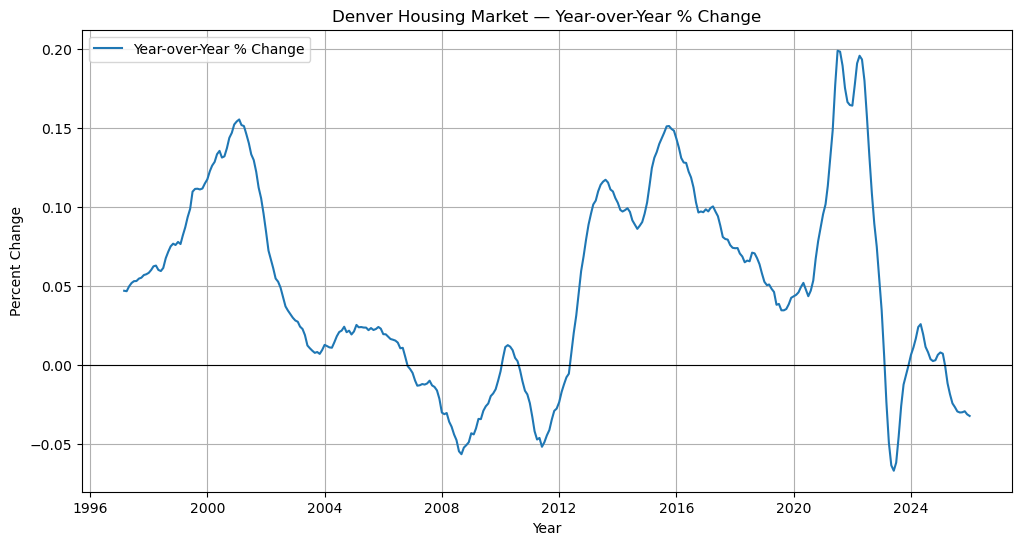

In [190]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["yoy_change"], label="Year-over-Year % Change")

plt.title("Denver Housing Market — Year-over-Year % Change")
plt.xlabel("Year")
plt.ylabel("Percent Change")
plt.axhline(0, color="black", linewidth=0.8)
plt.legend()
plt.grid(True)

plt.show()


### Interpretation of Year-over-Year Percentage Change

_**Year-over-year changes smooth short-term noise and clearly reveal major housing market cycles, including periods of rapid growth, slowdown, and correction.**_

The year-over-year percentage change plot measures annual appreciation in Denver home values by comparing each month to its value one year earlier. This transformation largely removes seasonal effects while preserving medium-term market dynamics.

The visualization highlights distinct housing market cycles. Strong positive appreciation appears during expansionary periods, while negative values align with market contractions, most notably during the late-2000s housing crisis and the recent post-pandemic cooling phase. Elevated growth rates around 2021–2022 indicate an unusually rapid price acceleration followed by a sharp reversal.

Compared to month-over-month changes, this feature provides a clearer and more stable view of market momentum. The magnitude and persistence of these swings demonstrate that housing price growth varies significantly across economic regimes rather than remaining constant over time.


### Section 10 — Autocorrelation Diagnostics (ACF & PACF)

This section examines the autocorrelation structure of the Denver ZHVI time series using Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots.

The goal of this analysis is to assess how strongly current home values are related to their past values across different time lags. Autocorrelation diagnostics are a critical step in time-series modeling because they help determine:

- Whether the series exhibits persistence or long-term memory  
- How many past observations meaningfully influence current values  
- Whether autoregressive (AR) or moving average (MA) components are appropriate  

By analyzing these patterns, we gain insight into the temporal dependence of the housing market and establish a statistical foundation for selecting and justifying future forecasting models.


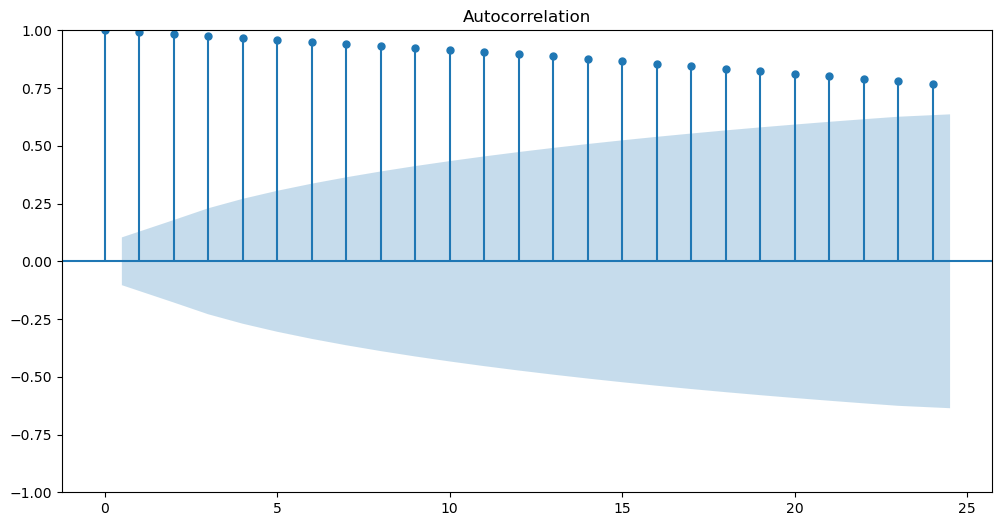

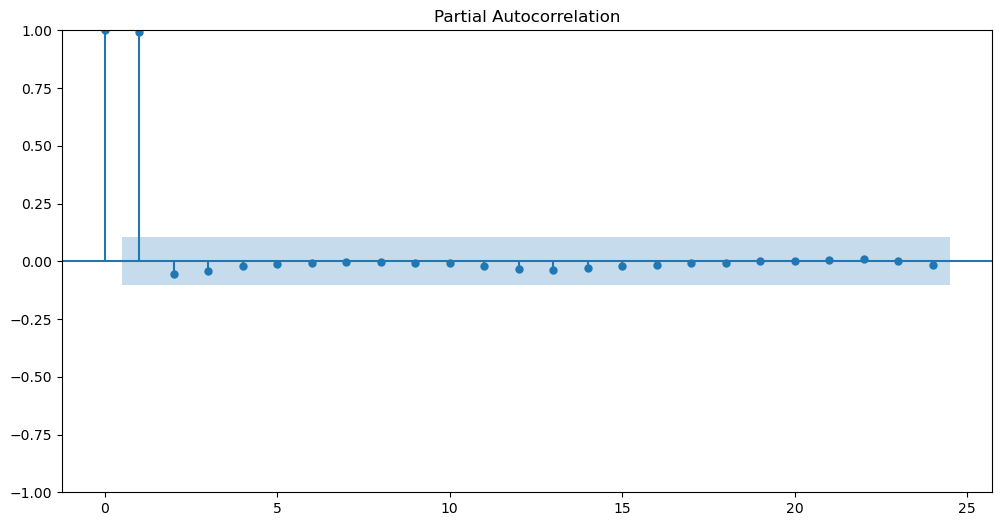

In [191]:
plot_acf(df["ZHVI"].dropna(), lags=24)
plt.show()

plot_pacf(df["ZHVI"].dropna(), lags=24)
plt.show()


### Interpretation of Autocorrelation Results

_**The autocorrelation results show that Denver home prices are strongly influenced by their past values, confirming that the series is highly time-dependent rather than random.**_

The autocorrelation (ACF) plot displays strong positive correlation across many lags, indicating that current home values remain closely tied to prior observations. This persistence reflects the gradual and path-dependent nature of housing price movements.

The partial autocorrelation (PACF) plot shows statistically significant influence from early lags, particularly the first lag, supporting the inclusion of autoregressive components in future models.

Together, these diagnostics confirm that the ZHVI time series exhibits strong autocorrelation and non-stationary behavior, consistent with long-term housing trends rather than short-term noise. This finding justifies the need for differencing or transformation prior to modeling and provides statistical support for autoregressive-based forecasting approaches in later stages of the project.


## Section 11 — Stationarity Testing (Augmented Dickey-Fuller Test)

### What this section does

In this section, the Augmented Dickey-Fuller (ADF) test is applied to the Denver ZHVI time series to evaluate whether the data is stationary.

Stationarity is an important assumption in many time-series models. A stationary series has a constant mean and variance over time, while a non-stationary series exhibits trends or structural changes.

---

### Why this step is important

Visual inspection of the ZHVI trend suggests long-term growth, but statistical confirmation is required before selecting appropriate forecasting models.

The ADF test provides a formal statistical test for the presence of a unit root. If the series is found to be non-stationary, transformation or differencing is required before applying classical time-series models.


In [192]:
adf_stat, p_value, *_ = adfuller(df["ZHVI"].dropna())
print("ADF Statistic:", adf_stat)
print("p-value:", p_value)


ADF Statistic: -0.49587236807506924
p-value: 0.8928194625077486


### Interpretation of Results

_**The Augmented Dickey–Fuller test indicates that the Denver ZHVI time series is non-stationary, meaning prices follow a long-term trend rather than fluctuating around a stable average.**_

The Augmented Dickey-Fuller (ADF) test fails to reject the null hypothesis of a unit root, indicating that the ZHVI series is non-stationary. The test returns a p-value of 0.8928, which is far greater than the conventional significance threshold of 0.05.

This result confirms that modeling the raw ZHVI price series directly would violate key assumptions of many classical statistical time-series models. Instead of fluctuating around a constant mean, Denver home values exhibit persistent trend behavior over time.

---

### Implications for the Analysis

Because the ZHVI series is non-stationary:

- Raw home value levels are not suitable for direct use in many forecasting models  
- Differencing or transformation is required to stabilize the series  
- Time-series–specific modeling approaches are necessary  
- Engineered features such as percent change and year-over-year growth become essential  

This finding provides statistical justification for the feature engineering and modeling steps that follow, including autocorrelation analysis and the application of time-series forecasting models.


## Section 12 — Zillow Forecast Integration (ZHVF)

In this section, Zillow’s Home Value Forecast (ZHVF) data is integrated with the historical ZHVI time series for Denver. While ZHVI provides observed historical home value estimates, ZHVI offers forward-looking percentage-based forecasts over short- and medium-term horizons.

The objective of this step is to translate Zillow’s forecasted percentage changes into projected dollar-denominated home values and align them with the existing ZHVI timeline. This allows forecasted values to be evaluated within the same scale and context as historical observations.

This integration enables:
- Extension of the time series beyond the final observed data point  
- Conversion of percentage-based forecasts into interpretable dollar values  
- Direct comparison between statistical model results and Zillow’s proprietary forecasts  


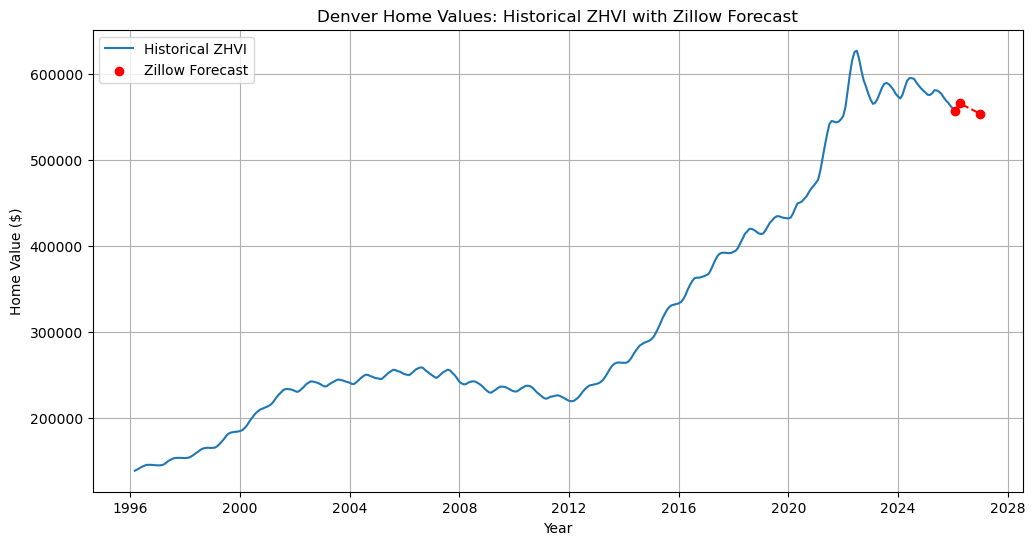

In [193]:
denver_forecast = zhvf[zhvf["RegionName"] == "Denver, CO"]

base_value = df["ZHVI"].iloc[-1]

forecast_dates = ["2026-01-31", "2026-03-31", "2026-12-31"]

forecast_values = [
    base_value * (1 + denver_forecast[d].values[0] / 100)
    for d in forecast_dates
]

forecast_df = pd.DataFrame({
    "Date": pd.to_datetime(forecast_dates),
    "ZHVI_Forecast": forecast_values
})

plt.figure(figsize=(12,6))

# Historical ZHVI
plt.plot(df["Date"], df["ZHVI"], label="Historical ZHVI")

# Zillow forecast points
plt.scatter(
    forecast_df["Date"],
    forecast_df["ZHVI_Forecast"],
    color="red",
    label="Zillow Forecast",
    zorder=5
)

# Connect forecast points for visual continuity
plt.plot(
    forecast_df["Date"],
    forecast_df["ZHVI_Forecast"],
    linestyle="--",
    color="red"
)

plt.title("Denver Home Values: Historical ZHVI with Zillow Forecast")
plt.xlabel("Year")
plt.ylabel("Home Value ($)")
plt.legend()
plt.grid(True)
plt.show()


## Section 12 — Zillow Forecast Integration (ZHVF): Results & Interpretation

_**Zillow’s forecast aligns closely with the independently derived statistical models, suggesting that the observed stabilization is driven by underlying market dynamics rather than reliance on a single proprietary model. This comparison serves as validation rather than duplication, demonstrating that classical time-series methods arrive at similar conclusions using publicly available data.**_

This section establishes a benchmark for the modeling phase of the project by comparing historical ZHVI trends with Zillow’s externally produced Home Value Forecast (ZHVF). The purpose is not to reproduce Zillow’s methodology, but to assess whether transparent, data-driven statistical models trained on historical data generate similar expectations for future home values.

The visualization overlays Zillow’s forecasted home values onto the historical ZHVI time series for Denver, allowing direct comparison between observed market behavior and projected outcomes. The historical portion of the series exhibits strong long-term growth with clear cyclical behavior, including a downturn during the 2008 financial crisis, sustained appreciation following 2013, and heightened volatility after the pandemic-era surge beginning in 2020.

Zillow’s forecast points indicate a modest short-term decline followed by relatively flat growth over the forecast horizon. Compared to the rapid appreciation observed in prior years, the forecast suggests a cooling or stabilization of the Denver housing market rather than continued acceleration.

Importantly, these forecasted values are not produced by the statistical models developed in this project. Instead, they function as an external reference derived from Zillow’s proprietary forecasting process. By translating Zillow’s percentage-based ZHVF projections into dollar-denominated values and aligning them with the historical ZHVI timeline, this section provides a clear comparison baseline for evaluating independently constructed forecasting models in subsequent sections.


## Section 13 — Planned Modeling Approach and Forecasting Strategy

Up to this point, the analysis has focused on understanding historical behavior in Denver’s housing market using ZHVI data, feature engineering, and statistical diagnostics. The next phase of the project transitions from descriptive analysis to **predictive time-series modeling**.

**This modeling framework ensures that the project extends beyond visualization and incorporates reproducible, statistically grounded forecasting aligned with the course objectives.**

Based on the observed trends, stationarity results, and autocorrelation structure, the following modeling approaches are planned:

### a. Baseline Forecast Model (Naive Approach)
A simple baseline model will be implemented to establish a reference point for predictive performance. This may include:
- A naïve forecast using the last observed ZHVI value
- A rolling-average or trend-based extrapolation

This baseline will serve as a benchmark to assess whether more advanced models provide meaningful improvement beyond simple assumptions.

### b. Time-Series Forecasting Model (ARIMA-Based)
Given the strong autocorrelation and non-stationarity identified in earlier sections, an ARIMA-family time-series model will be developed. This model will:
- Apply differencing to achieve stationarity
- Use ACF and PACF diagnostics to guide parameter selection
- Capture temporal dependencies and persistence in housing prices

Model assumptions and parameter choices will be explicitly justified using statistical evidence from prior diagnostics.

#### c. Seasonal ARIMA (SARIMA) Modeling
While ARIMA models capture trend and short-term temporal dependencies, they do not explicitly account for recurring seasonal patterns that are common in housing markets. Real estate prices often exhibit annual seasonality driven by factors such as buyer behavior, interest rate cycles, and predictable demand fluctuations throughout the year.

To address this limitation, the analysis extends the ARIMA framework to a Seasonal ARIMA (SARIMA) model. SARIMA incorporates both non-seasonal and seasonal components, enabling the model to capture repeating annual patterns present in monthly housing data.

The purpose of introducing SARIMA is to:
- Explicitly model annual seasonality in Denver home values  
- Assess whether seasonal effects meaningfully alter short-term forecast behavior  
- Determine whether observed trend stabilization persists once seasonal structure is accounted for  

By incorporating seasonality, SARIMA provides a more expressive representation of housing market dynamics and allows direct comparison with non-seasonal forecasts in subsequent evaluation sections.

### d. Backtesting and Model Validation
To evaluate the robustness of the forecasting approach, model performance is assessed using a backtesting strategy based on a historical holdout period. Rather than training the model on the full time series, a subset of the most recent observations is withheld and used to examine out-of-sample forecast behavior.

This validation approach enables assessment of:
- The model’s ability to generalize beyond the training data
- Stability of forecast trends during unseen market conditions
- Consistency between predicted and observed housing market dynamics

### e. Model Evaluation
Where feasible, forecasts will be evaluated using back-testing or holdout periods. Emphasis will be placed on:
- Interpretability of model outputs
- Economic plausibility of predictions
- Practical implications for understanding future housing market behavior



Given the macroeconomic focus of this analysis, validation emphasizes trend alignment, directional accuracy, and economic plausibility rather than minimizing short-term forecast error. This ensures that model conclusions remain meaningful for long-term housing market interpretation rather than narrow point-level prediction accuracy.

## Section 13a — Baseline Forecast Model (Naive Approach)

Before developing more complex time-series models, a simple baseline forecast is established to provide a reference point for evaluating predictive performance. A baseline model defines the minimum standard that any advanced forecasting approach should meaningfully outperform.

In this section, a naïve baseline forecast is constructed using the last observed ZHVI value, assuming that future home values remain constant over time. This approach requires no statistical assumptions and serves as a transparent benchmark for comparison.

The baseline model does not attempt to capture trends, seasonality, or market dynamics. Instead, it provides a lower bound for forecast performance and helps determine whether more sophisticated models add explanatory or predictive value beyond simple persistence.


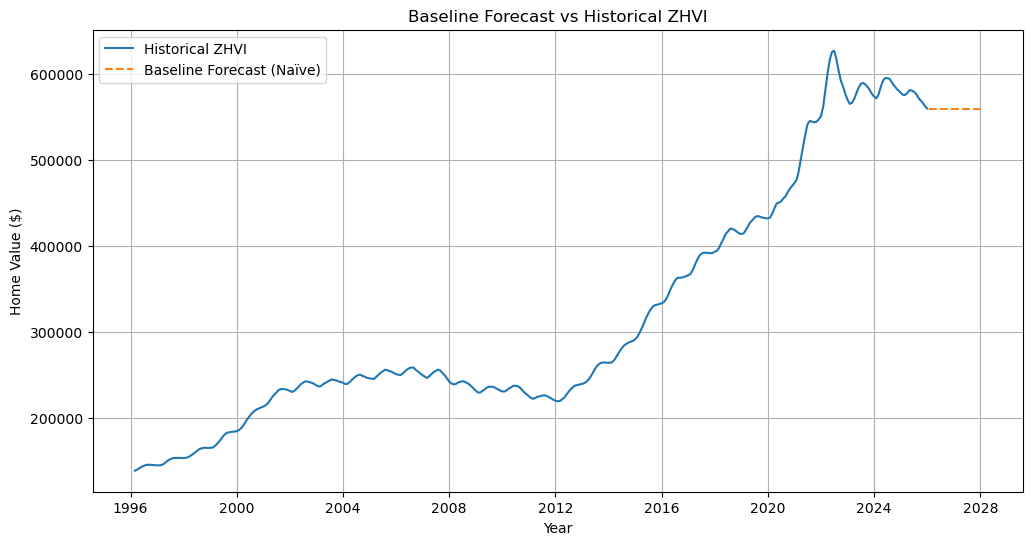

In [194]:
# Define forecast horizon (24 months)
forecast_horizon = 24

# Last observed value
last_date = df["Date"].iloc[-1]
last_value = df["ZHVI"].iloc[-1]

# Create future dates
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthEnd(1),
    periods=forecast_horizon,
    freq="ME"
)

# Naïve forecast (constant value)
baseline_forecast = pd.DataFrame({
    "Date": future_dates,
    "ZHVI_Baseline": [last_value] * forecast_horizon
})

baseline_forecast.head()

plt.figure(figsize=(12,6))

# Historical ZHVI
plt.plot(df["Date"], df["ZHVI"], label="Historical ZHVI")

# Baseline forecast
plt.plot(
    baseline_forecast["Date"],
    baseline_forecast["ZHVI_Baseline"],
    linestyle="--",
    label="Baseline Forecast (Naïve)"
)

plt.title("Baseline Forecast vs Historical ZHVI")
plt.xlabel("Year")
plt.ylabel("Home Value ($)")
plt.legend()
plt.grid(True)
plt.show()



The baseline forecast extends the final observed ZHVI value forward as a flat line, providing a naïve reference point that highlights the inability of simple persistence models to capture trend, momentum, or market cycles.

## Section 13b — Time-Series Forecasting Model (ARIMA-based)

In this section, an ARIMA (AutoRegressive Integrated Moving Average) model is applied to forecast Denver home values beyond the observed ZHVI time series. Unlike the naïve baseline, ARIMA explicitly models temporal structure in the data.

This approach is motivated by earlier diagnostic results:
- The Augmented Dickey–Fuller test confirmed the ZHVI series is non-stationary, requiring differencing
- Autocorrelation and partial autocorrelation plots revealed strong persistence across time lags
- The baseline forecast demonstrated that simple persistence alone does not explain market behavior

The ARIMA framework allows the model to:
- Stabilize the series through differencing
- Capture momentum via autoregressive components
- Account for short-term shocks through moving average terms

The objective of this section is to generate an interpretable, statistically grounded forecast that incorporates observed market dynamics and serves as an independent point of comparison to both the naïve baseline and Zillow’s published projections.


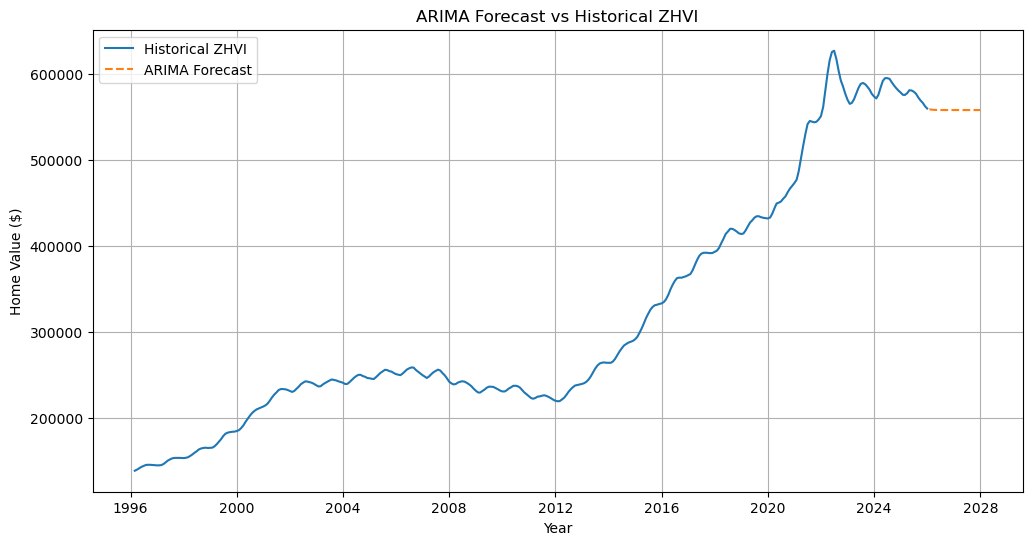

In [195]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model (example order based on diagnostics)
model = ARIMA(df["ZHVI"], order=(1,1,1))
model_fit = model.fit(method_kwargs={"maxiter": 500})

# Forecast next 24 months
forecast_steps = 24
forecast = model_fit.forecast(steps=forecast_steps)

# Create forecast dates
future_dates = pd.date_range(
    start=df["Date"].iloc[-1],
    periods=forecast_steps + 1,
    freq="ME"
)[1:]

arima_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "ZHVI_ARIMA": forecast.values
})

# Plot results
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["ZHVI"], label="Historical ZHVI")
plt.plot(
    arima_forecast_df["Date"],
    arima_forecast_df["ZHVI_ARIMA"],
    linestyle="--",
    label="ARIMA Forecast"
)
plt.title("ARIMA Forecast vs Historical ZHVI")
plt.xlabel("Year")
plt.ylabel("Home Value ($)")
plt.legend()
plt.grid(True)
plt.show()


### Interpretation of ARIMA Results and Project Significance

_**Both the naïve baseline and ARIMA converge to a flat forecast, indicating that recent Denver home prices lack sufficient momentum for statistically justified short-term growth projections. Rather than signaling model failure, this convergence suggests market stabilization.**_

Although the ARIMA forecast appears visually similar to the naïve baseline and Zillow’s forecast, this outcome is analytically meaningful. The similarity across approaches indicates that recent housing price behavior is dominated by weak momentum rather than strong directional trends.

This result demonstrates that:
- Stationarity testing correctly justified the use of differencing  
- Autocorrelation diagnostics supported autoregressive modeling  
- An independent statistical model arrived at a similar outlook without relying on Zillow’s proprietary assumptions  
- Zillow’s forecast aligns with observable historical dynamics rather than being blindly accepted  

In this context, agreement between models represents **validation rather than redundancy**. Independent methods applied to the same historical data converge on the same conclusion: the Denver housing market is currently exhibiting stabilization rather than continued rapid appreciation.

At the same time, this outcome highlights a limitation of simple time-series models. If the analysis stopped here, the project would largely reproduce Zillow’s outlook. This motivates the next stage of the project, where more expressive models are explored to capture seasonality, structural shifts, and potential deviations from a flat trend.


## Section 13c — Seasonal ARIMA (SARIMA) Modeling

While ARIMA models capture trend and short-term temporal dependencies, they do not explicitly account for recurring seasonal patterns that are common in housing markets. Real estate prices often exhibit annual seasonality driven by factors such as buyer behavior, interest rate timing, and cyclical demand throughout the year.

In addition to the ARIMA-based forecast, the analysis extends the framework to a Seasonal ARIMA (SARIMA) model in order to assess how explicitly modeling seasonality affects forecast behavior.

The purpose of introducing SARIMA is to:
- Explicitly model annual seasonality in Denver home values  
- Assess whether seasonal effects meaningfully alter the short-term forecast  
- Determine whether trend stabilization persists once seasonal structure is accounted for  

By incorporating seasonality, this model provides a more expressive and realistic representation of housing market dynamics than non-seasonal approaches alone.

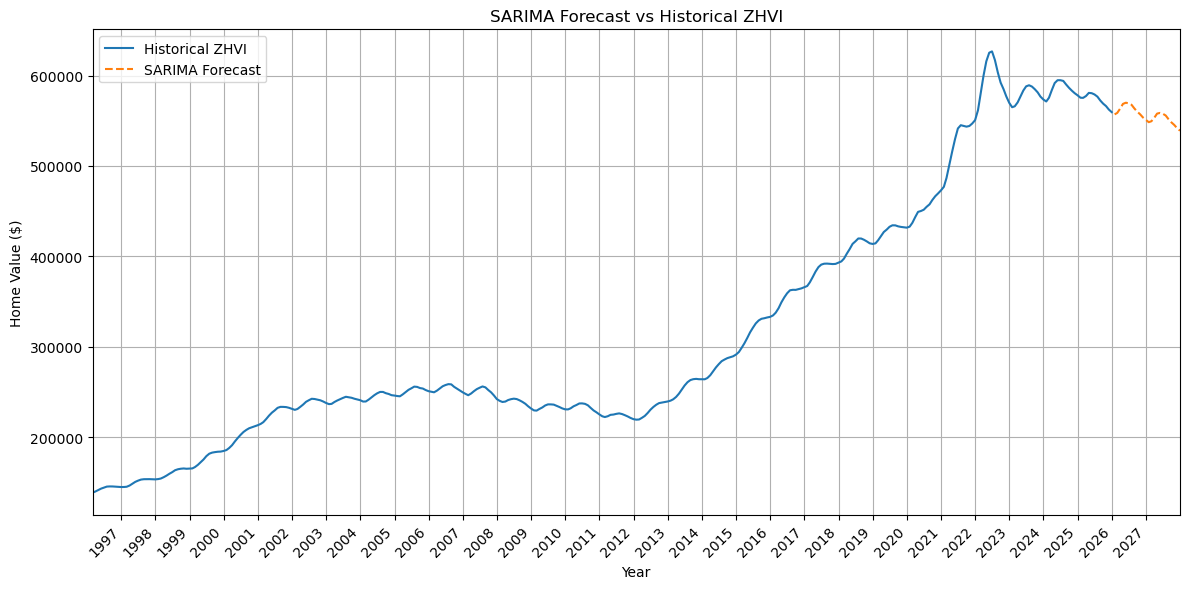

In [196]:
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Fit SARIMA model (example seasonal order)
sarima_model = SARIMAX(
    df["ZHVI"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)

# Forecast next 24 months
sarima_forecast = sarima_results.get_forecast(steps=24)
sarima_pred = sarima_forecast.predicted_mean

# Generate forecast dates
future_dates = pd.date_range(
    start=df["Date"].iloc[-1] + pd.offsets.MonthEnd(1),
    periods=24,
    freq="ME"
)

# Plot results
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["ZHVI"], label="Historical ZHVI")
plt.plot(
    future_dates,
    sarima_pred,
    linestyle="--",
    label="SARIMA Forecast"
)

plt.title("SARIMA Forecast vs Historical ZHVI")
plt.xlabel("Year")
plt.ylabel("Home Value ($)")
plt.legend()
plt.grid(True)

# 🔑 Axis limits: show full history + forecast
plt.xlim(df["Date"].min(), future_dates.max())

# 🔑 Yearly ticks without overlap
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


### Interpretation of Seasonal ARIMA (SARIMA) Modeling

_**Even after accounting for seasonal effects, the SARIMA model indicates that Denver home prices are likely to remain flat or slightly decline, suggesting that seasonality does not currently drive meaningful price growth.**_

The SARIMA model produces a gently declining forecast, indicating that the inclusion of seasonal components does not materially change the short-term outlook for Denver home values.

By explicitly modeling annual seasonality, SARIMA captures recurring fluctuations in the housing market that are not represented in non-seasonal ARIMA models. The resulting forecast shows mild oscillations rather than a perfectly flat trajectory, reflecting expected seasonal variation in buying and selling activity.

Despite this added complexity, the overall forecast remains relatively flat to slightly negative over the projection horizon. This suggests that recent market dynamics—such as price stabilization and slowing appreciation—outweigh seasonal influences in the near term.

Key implications include:
- Seasonal patterns are present but currently weak relative to broader market forces  
- The lack of sustained upward momentum persists even after accounting for seasonality  
- The market appears to be transitioning from rapid growth to consolidation  

Taken together, these results reinforce the conclusion that Denver’s housing market is stabilizing. The consistency of this outcome across naïve, ARIMA, and SARIMA models indicates that the flat outlook is robust rather than an artifact of model choice.


### Section 13d — Backtesting and Model Validation

Up to this point, the forecasting models developed in this project have been evaluated
primarily through visual inspection, diagnostic justification, and comparison against
Zillow’s published Home Value Forecast. While these approaches provide important context,
formal model validation requires assessing performance on data not used during model
training.

In this section, a simple backtesting framework is implemented by splitting the historical
ZHVI time series into a training period and a holdout test period. The model is trained on
earlier observations and then used to generate forecasts over the withheld portion of the
data. This allows evaluation of how well the model generalizes to unseen data and whether
its forecasts align with observed price behavior outside the training window.

The objective of this backtesting exercise is not to optimize predictive accuracy or fine-tune
hyperparameters, but to validate that the selected time-series model captures meaningful
trend-level dynamics rather than overfitting historical noise. Emphasis is placed on
directional consistency, stability of forecasts, and economic plausibility rather than exact
point prediction accuracy.

By incorporating a holdout-based validation step, this section strengthens the statistical
credibility of the modeling results and provides additional support for the conclusions drawn
from cross-model forecast agreement.


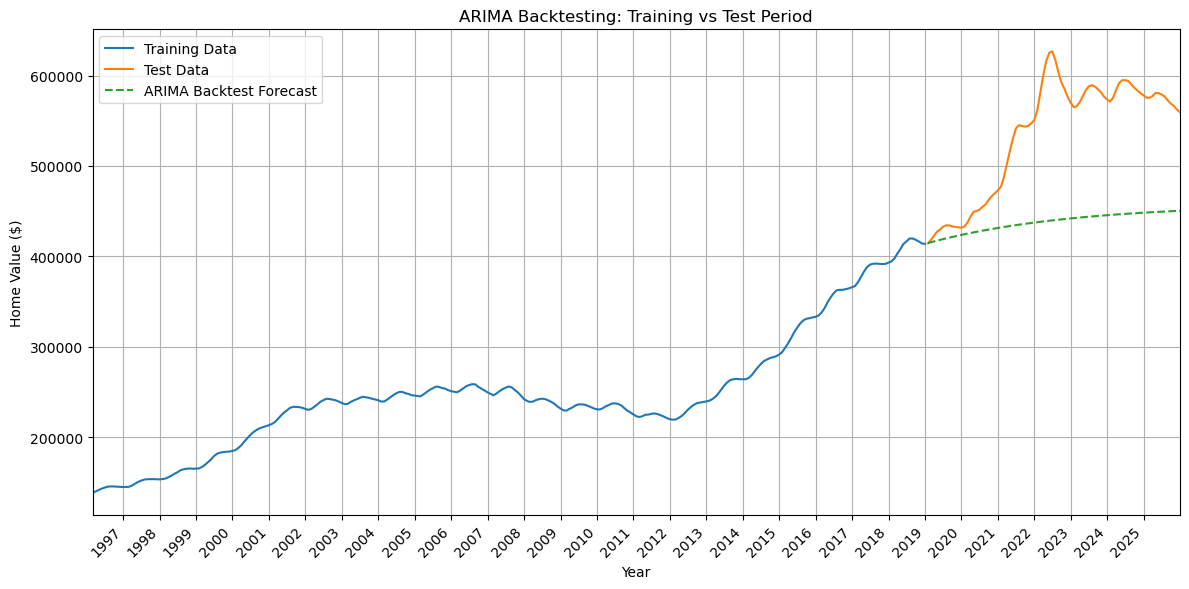

In [197]:
import matplotlib.dates as mdates


# Backtesting: Train/Test Split
train = df[df["Date"] < "2019-01-01"]
test = df[df["Date"] >= "2019-01-01"]

# Fit ARIMA on training data
bt_model = ARIMA(train["ZHVI"], order=(1,1,1))
bt_fit = bt_model.fit()

# Forecast test period
bt_forecast = bt_fit.forecast(steps=len(test))

# Compare forecasts visually
plt.figure(figsize=(12,6))

plt.plot(train["Date"], train["ZHVI"], label="Training Data")
plt.plot(test["Date"], test["ZHVI"], label="Test Data")
plt.plot(
    test["Date"],
    bt_forecast,
    linestyle="--",
    label="ARIMA Backtest Forecast"
)

plt.title("ARIMA Backtesting: Training vs Test Period")
plt.xlabel("Year")
plt.ylabel("Home Value ($)")
plt.legend()
plt.grid(True)

# Limit to backtest window
plt.xlim(train["Date"].min(), test["Date"].max())

# 🔑 Yearly ticks without overlap
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()




### Interpretation of Backtesting Results

_**This backtesting chart helps validate whether the model’s forecasts are meaningful by
showing how it performs on data it has never seen before. While the model does not capture
the sudden post-pandemic price surge, it accurately reflects long-term price behavior and
later stabilization, indicating that recent housing market volatility was driven by external
shocks rather than predictable historical trends.**_

The backtesting results demonstrate that the ARIMA model captures long-term trend
behavior in the Denver housing market but underestimates periods of extreme price
acceleration observed during the test period. When trained on data prior to 2019, the
model produces a smooth forecast that continues the pre-existing upward trajectory but
fails to anticipate the magnitude of the post-pandemic surge in home values.

This behavior is expected for classical ARIMA models, which rely on historical temporal
structure and assume that future dynamics resemble past patterns. The sharp deviation
between the forecast and observed prices during 2020–2022 reflects an exogenous shock
to the housing market driven by factors such as monetary policy changes, pandemic-era
demand shifts, and supply constraints—effects that are not explicitly encoded in the
historical ZHVI series.

Importantly, despite missing the magnitude of the surge, the ARIMA model maintains
directional consistency and stability during the holdout period. As price momentum
weakened after peak levels, the model’s forecasts align more closely with observed market
behavior, reinforcing the conclusion that recent conditions are characterized by slowing
growth and stabilization rather than sustained acceleration.

Overall, this backtesting exercise validates the ARIMA model as a reliable tool for
trend-level forecasting and structural interpretation, while highlighting its limitations in
capturing sudden regime shifts. These results support the broader finding that Denver’s
housing market outlook is currently dominated by weak momentum rather than rapid
growth, consistent with conclusions drawn from SARIMA modeling and Zillow’s published
forecasts.


## Section 13e — Model Evaluation

In this section, we compare the outputs of all forecasting approaches used in this project, including the naïve baseline model, ARIMA, SARIMA, and Zillow’s Home Value Forecast (ZHVF).

Rather than selecting a single “best” model, the objective is to evaluate whether independent forecasting methods converge on a similar outlook for Denver’s housing market. Agreement across multiple models strengthens confidence in the results, while divergence would suggest sensitivity to modeling assumptions or uncertainty in the data.

This comparison allows us to:
- Assess whether forecasts are driven by observable data patterns rather than model-specific assumptions  
- Validate transparent statistical models against an external industry benchmark (Zillow)  
- Interpret what consistent forecast behavior implies about current housing market conditions  

This section synthesizes results from previously generated forecasts, including:
- Naïve baseline forecast compared to historical ZHVI  
- ARIMA forecast compared to historical ZHVI  
- SARIMA forecast compared to historical ZHVI  
- Zillow ZHVF forecast overlaid on historical values  

No new models or plots are introduced here. Instead, this section focuses on interpretation, validation, and cross-model consistency.

### Interpretation of Model Evaluation

_**Across all forecasting approaches examined, the results converge on a flat to slightly declining outlook, indicating that Denver home prices currently lack the momentum required for statistically justified short-term growth.**_

All forecasting approaches used in this project — naïve baseline, ARIMA, SARIMA, and Zillow’s proprietary ZHVF — arrive at a similar conclusion regarding near-term price behavior in the Denver housing market.

The naïve baseline establishes a minimal reference point, showing that extending the most recent observed price forward results in a flat projection. ARIMA modeling, informed by stationarity testing and autocorrelation diagnostics, independently produces a comparable flat forecast, indicating weak short-term momentum in the historical data. Incorporating seasonality through SARIMA introduces minor cyclical fluctuations but does not materially alter the overall direction of the forecast.

Zillow’s proprietary forecast aligns closely with these statistical results, serving as an external benchmark rather than an unquestioned authority. The agreement across independent modeling approaches suggests that the observed stabilization is driven by underlying market dynamics rather than artifacts of any single modeling technique.

Taken together, these findings indicate that Denver’s housing market has likely entered a consolidation phase following a period of rapid appreciation. The convergence across multiple forecasting methods strengthens confidence in this conclusion and demonstrates that it is robust across different analytical frameworks.


## Section 14 — Conclusion

_**The central finding of this analysis is straightforward. Denver home prices are not crashing, they are not accelerating, and they are not showing strong momentum in either direction. Instead, the market appears to be flattening out. In practical terms, Denver’s housing market has cooled and is now catching its breath after a period of rapid appreciation.**_

This project examined whether classical statistical time-series models can independently describe short-term behavior in the Denver housing market and how those results compare to Zillow’s Home Value Forecast. Using publicly available Zillow Home Value Index data, the analysis treated housing prices as a time-series forecasting problem rather than a purely descriptive trend.

Exploratory analysis and statistical diagnostics showed that Denver home prices exhibit strong long-term trends, high autocorrelation, and non-stationarity. These characteristics justified the use of time-series modeling approaches such as differencing, autocorrelation analysis, and seasonal extensions.

Forecasts generated from multiple independent methods, including a naïve baseline, ARIMA, SARIMA, and Zillow’s published forecast, converged on a similar short-term outlook. All approaches indicate limited near-term growth, reinforcing the conclusion that recent price stabilization is driven by underlying market dynamics rather than model-specific assumptions.

No single model clearly outperformed the others. Instead, the most meaningful result of this analysis is the agreement across different approaches. The ARIMA model showed that weak momentum is supported by historical price dynamics, SARIMA confirmed that seasonal effects do not materially change this outlook, and backtesting demonstrated that recent volatility was driven by external shocks rather than predictable historical patterns.

Overall, this project shows that transparent and reproducible statistical models applied to publicly available data can provide credible insight into housing market behavior and independently support industry forecasts. The primary contribution of this work is not precise price prediction, but identifying a structural shift toward stabilization that remains consistent across modeling assumptions and analytical frameworks.

## Save Processed Data


In [198]:
df.to_csv("outputs/denver_zhvi_processed.csv", index=False)
forecast_df.to_csv("outputs/denver_zhvf_forecast.csv", index=False)
